# Proyek Analisis Data: Deteksi Emosi Wajah (FER-2013) untuk Interview-AI
- **Nam: *Monica Dyah Pudyowati*]
- **Pen: * Data Scien****st

## Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Bagaimana distribusi kelas emosi pada dataset FER-2013, dan apakah terdapat ketidakseimbangan data (imbalanced data)?
- Pertanyaan 2: Bagaimana cara mengatasi ketidakseimbangan data agar model AI tidak bias saat melakukan deteksi?

## Import Semua Packages/Library yang Digunakanet* yang perlu ditangani.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling
### Gathering Data

In [7]:
dataset_path = 'train' 

emotions = os.listdir(dataset_path)
emotion_counts = {}

for emotion in emotions:
    folder_path = os.path.join(dataset_path, emotion)
    if os.path.isdir(folder_path):
        emotion_counts[emotion] = len(os.listdir(folder_path))

df_emotions = pd.DataFrame(list(emotion_counts.items()), columns=['Kategori Emosi', 'Jumlah Gambar'])
df_emotions = df_emotions.sort_values(by='Jumlah Gambar', ascending=False)

**Insight Gathering Data:**
- Dataset berhasil dimuat dari folder lokal.
- Terdapat 7 kategori emosi wajah yang terdeteksi.

### Assessing Data

Jumlah data per kategori:
Kategori Emosi  Jumlah Gambar
         happy           7215
       neutral           4965
           sad           4830
          fear           4097
         angry           3995
      surprise           3171
       disgust            436
------------------------------


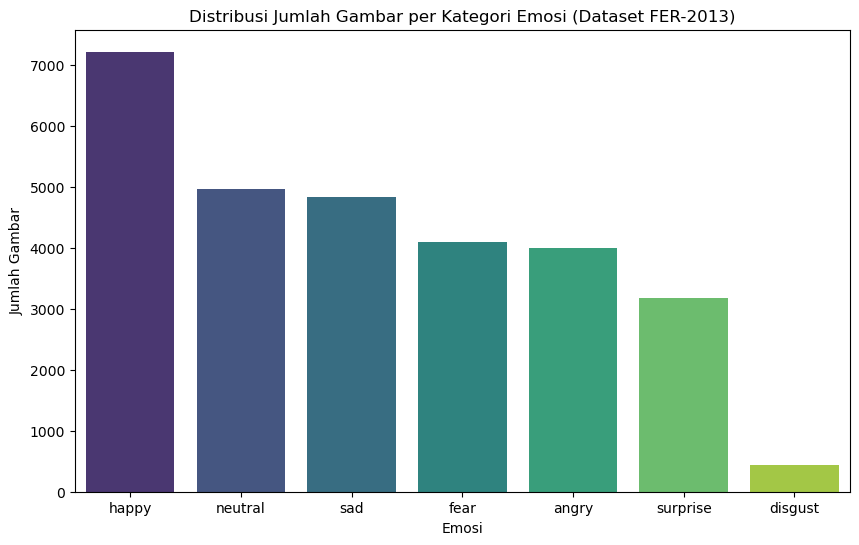

In [9]:
print("Jumlah data per kategori:")
print(df_emotions.to_string(index=False))
print("-" * 30)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kategori Emosi', y='Jumlah Gambar', data=df_emotions, hue='Kategori Emosi', palette='viridis', legend=False)
plt.title('Distribusi Jumlah Gambar per Kategori Emosi (Dataset FER-2013)')
plt.xlabel('Emosi')
plt.ylabel('Jumlah Gambar')
plt.show()

**Insight Assessing Data:**
- Emosi terbanyak adalah "Happy" (7215 gambar).
- Emosi paling sedikit adalah "Disgust" (436 gambar).
- Terdapat masalah *Imbalanced Dataset* yang cukup parah yang harus ditangani pada tahap *Cleaning Data*.

### Cleaning DataMmenyatukan seluruh *path* gambar ke dalam satu DataFrame agar mudah diproses oleh model. Selanjutnyaa melakukan teknik **Undersampling** pada kelas dominan ("Happy") untuk mengurangi bias pada model AI.

In [23]:
file_paths = []
labels = []

for emotion in emotions:
    folder_path = os.path.join(dataset_path, emotion)
    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            file_paths.append(os.path.join(folder_path, file_name))
            labels.append(emotion)

df_full = pd.DataFrame({'File_Path': file_paths, 'Label': labels})

df_happy = df_full[df_full['Label'] == 'happy'].sample(n=4000, random_state=42)

df_other = df_full[df_full['Label'] != 'happy']

df_cleaned = pd.concat([df_happy, df_other]).reset_index(drop=True)

print("Distribusi Data Setelah Cleaning (Undersampling):")
print(df_cleaned['Label'].value_counts())
print("-" * 30)
print(f"Total data siap pakai: {len(df_cleaned)} gambar")

df_cleaned.head()

Distribusi Data Setelah Cleaning (Undersampling):
Label
neutral     4965
sad         4830
fear        4097
happy       4000
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64
------------------------------
Total data siap pakai: 25494 gambar


,File_Path,Label
0,train\happy\Training_13605151.jpg,happy
1,train\happy\Training_1460262.jpg,happy
2,train\happy\Training_50261638.jpg,happy
3,train\happy\Training_38735724.jpg,happy
4,train\happy\Training_12925472.jpg,happy


**Insight Cleaning Data:**
- Seluruh *path* file gambar berhasil diekstrak ke dalam bentuk tabular (DataFrame) untuk memudahkan proses *training* model oleh tim AI.
- Dilakukan *Undersampling* pada kelas "Happy" menjadi 4000 data untuk mengurangi ketimpangan data tanpa menghilangkan variasi ekspresi dasar.
- Data kini lebih siap untuk tahap Eksplorasi Data Lanjutan (EDA) dan *Training*.

## Exploratory Data Analysis (EDA) Lanjutan
### Visualisasi Sampel Gambar Wajah
Sebagai validasi akhir pada tahap data wrangli makata akan menampilkan beberapa sampel gambar secara acak dari dataset yang sudah dibersihkan untuk memastikan gambar dapat dibaca dengan baik dan labelnya sesuai dengan ekspresi wajah.

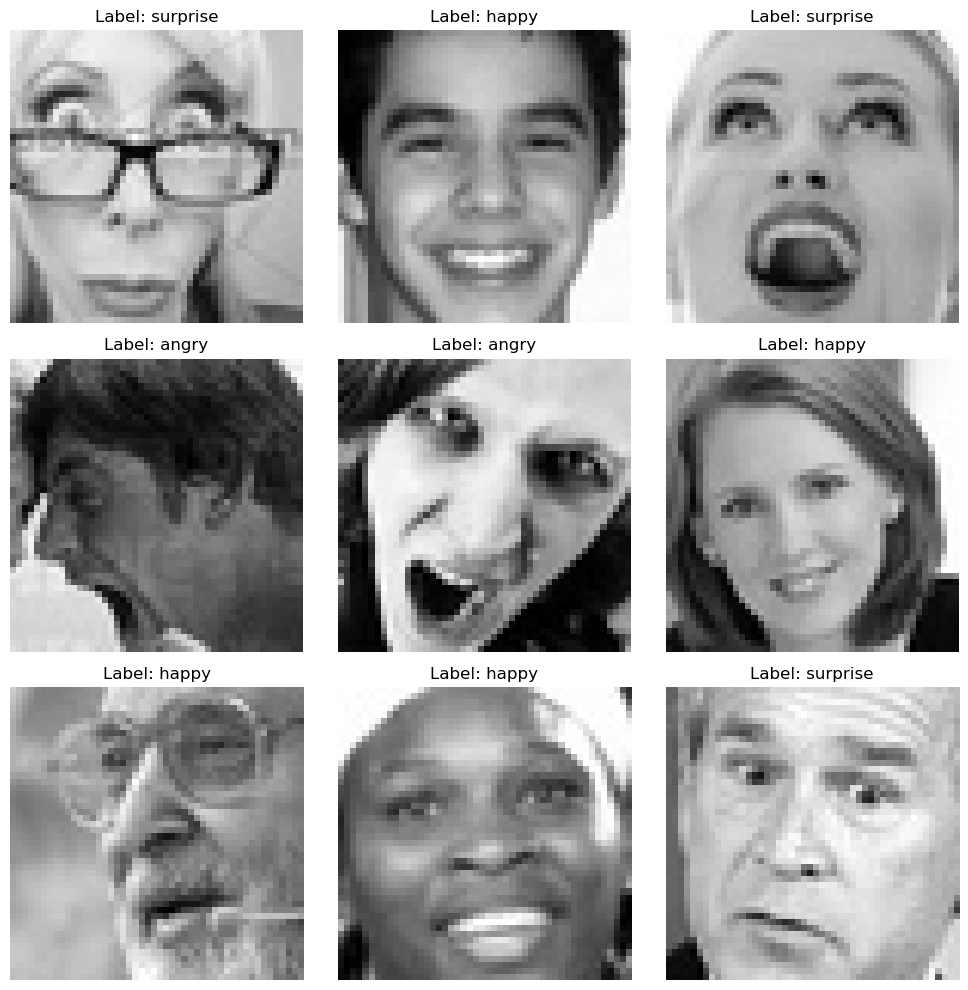

In [25]:
import matplotlib.image as mpimg
import random

plt.figure(figsize=(10, 10))

for i in range(9):
    
    plt.subplot(3, 3, i + 1)
    
    acak = random.randint(0, len(df_cleaned) - 1)
    img_path = df_cleaned.iloc[acak]['File_Path']
    label = df_cleaned.iloc[acak]['Label']
    
    img = mpimg.imread(img_path)
    
    plt.imshow(img, cmap='gray')
    
    plt.title(f"Label: {label}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi kelas emosi pada dataset FER-2013, dan apakah terdapat ketidakseimbangan data (imbalanced data)?
### Pertanyaan 2: Bagaimana cara mengatasi ketidakseimbangan data agar model AI tidak bias saat melakukan deteksi?

Untuk menjawab kedua pertanyaan di maka perlu akan membandingkan visualisasi distribusi data sebelum dan sesudah tahap *Cleaning Data* (Undersampling).

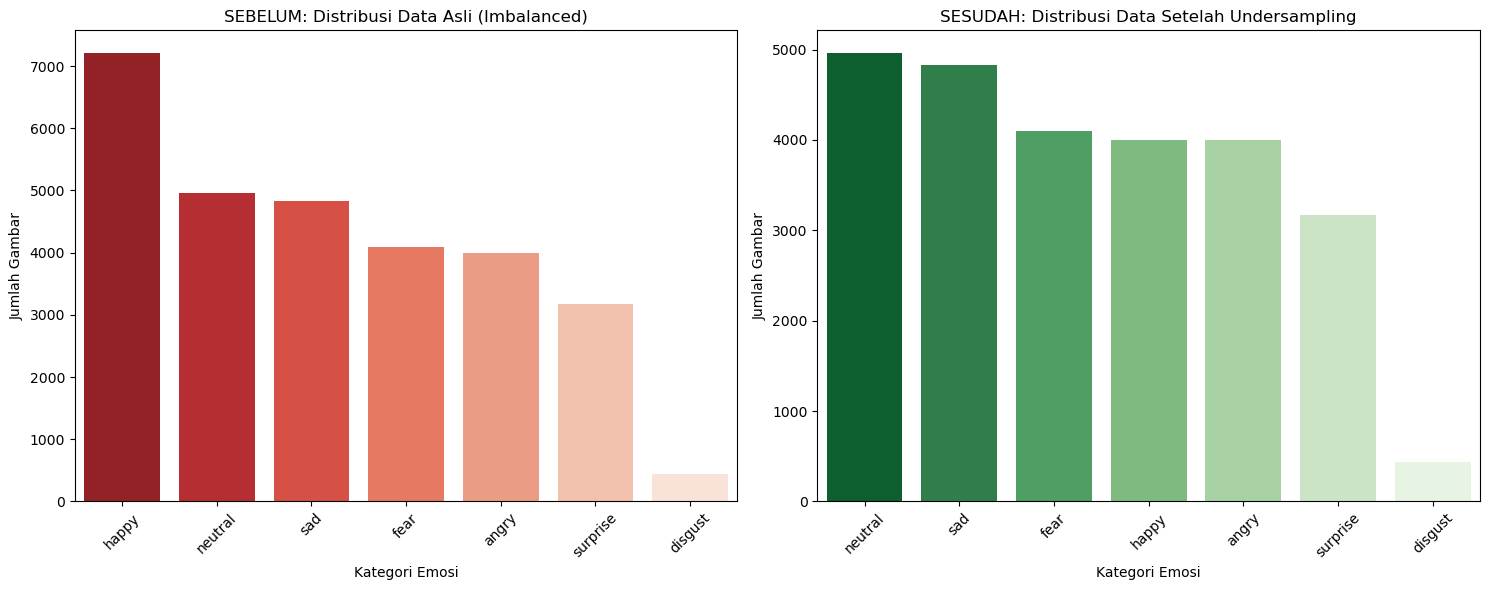

In [27]:
df_cleaned_counts = df_cleaned['Label'].value_counts().rename_axis('Kategori Emosi').reset_index(name='Jumlah Gambar')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(ax=axes[0], x='Kategori Emosi', y='Jumlah Gambar', data=df_emotions, hue='Kategori Emosi', palette='Reds_r', legend=False)
axes[0].set_title('SEBELUM: Distribusi Data Asli (Imbalanced)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='Kategori Emosi', y='Jumlah Gambar', data=df_cleaned_counts, hue='Kategori Emosi', palette='Greens_r', legend=False)
axes[1].set_title('SESUDAH: Distribusi Data Setelah Undersampling')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

- **Conclusion Pertanyaan 1:** Berdasarkan visualisasi awal, dataset FER-2013 memiliki ketidakseimbangan kelas (*imbalanced data*) yang signifikan. Kategori emosi "Happy" sangat mendominasi dengan lebih dari 7.000 gambar, sedangkan emosi "Disgust" hanya memiliki sekitar 400 gambar. Ketimpangan ini berisiko membuat model AI menjadi bias dan cenderung selalu menebak "Happy".

- **Conclusion Pertanyaan 2:** Untuk mengatasi ketidakseimbangan tersebut, telah dilakukan teknik *Undersampling* pada tahap *Cleaning Data*. Jumlah gambar pada kelas "Happy" dipangkas secara acak menjadi 4.000 gambar agar jumlahnya lebih seimbang dengan kelas mayoritas lainnya seperti "Neutral", "Sad", "Fear", dan "Angry". Dengan distribusi data yang lebih merata ini (total 25.494 gambar siap pakai), dataset kini jauh lebih sehat dan siap diserahkan kepada tim AI untuk proses *Training* model *Deep Learning*.

In [29]:
df_cleaned.to_csv('fer2013_cleaned_data.csv', index=False)
print("Data berhasil disimpan ke 'fer2013_cleaned_data.csv'!")

Data berhasil disimpan ke 'fer2013_cleaned_data.csv'!
